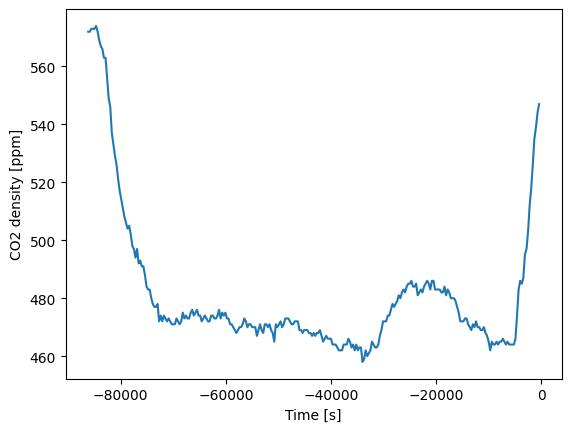

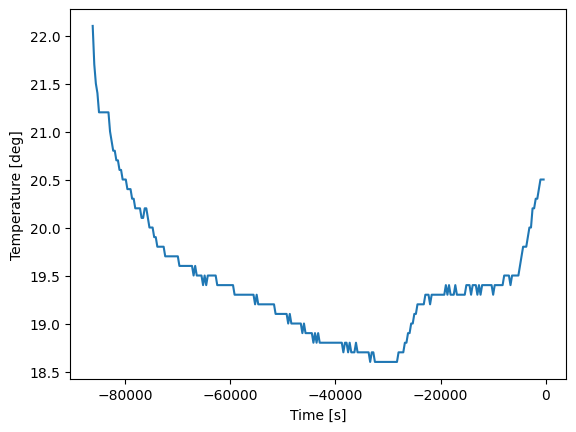

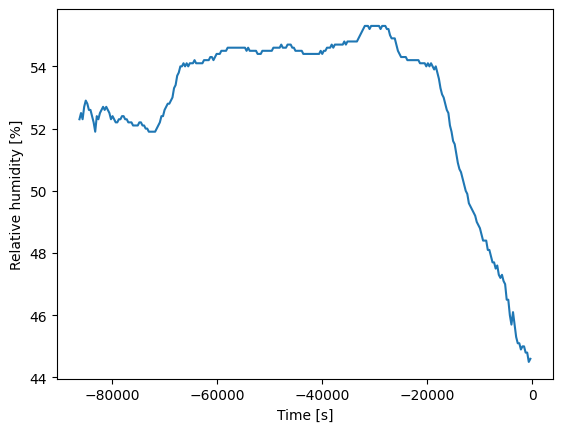

In [1]:
import time
import sys
import csv
import matplotlib.pyplot as plt
import numpy as np
import requests

curr_time = int(time.time())
tt = curr_time - 3600*24   # 24時間前
res = requests.get(f'https://airoco.necolico.jp/data-api/day-csv?id=CgETViZ2&subscription-key=6b8aa7133ece423c836c38af01c59880&startDate={tt}')

raw_data = csv.reader(res.text.strip().splitlines())
data=[]
for row in raw_data:
    if row[1]=='Ｒ３ー４０１':
        data.append(list(map(float, row[3:7])))

if data==[]:
  print("This sensor is not connected")
else:
  data = np.array(data)
  data[:,3] -= curr_time # 時刻を現在から何秒前かにする

  plt.plot(data[:,3],data[:,0])
  plt.xlabel('Time [s]')
  plt.ylabel('CO2 density [ppm]')
  plt.show()
  plt.plot(data[:,3],data[:,1])
  plt.xlabel('Time [s]')
  plt.ylabel('Temperature [deg]')
  plt.show()
  plt.plot(data[:,3],data[:,2])
  plt.xlabel('Time [s]')
  plt.ylabel('Relative humidity [%]')
  plt.show()